# Full Fine-Tuning vs. LoRA (PEFT) for Dialogue Summarization

Trains **FLAN-T5-base** two ways on [DialogSum](https://huggingface.co/datasets/knkarthick/dialogsum) —
full fine-tuning (every parameter updated) vs. a **LoRA adapter** (base
frozen) — and compares both against the untouched zero-shot model on ROUGE,
training time, and trainable-parameter percentage. Also runs a LoRA rank
sweep (r = 4/16/32).

Reuses the `src/` package from the companion GitHub repo.

> **Kaggle setup:** this notebook trains real models, so you need a GPU.
> Under *Notebook Settings*, set **Accelerator** to a GPU (T4 x2 or P100) and
> turn **Internet** ON (needed to clone the repo and download the
> model/dataset from Hugging Face).

In [1]:
# Install pinned dependencies.
# torchao is preinstalled on Kaggle at a version incompatible with peft's
# LoRA code path (which probes for it even though this project never uses
# it) -- uninstalling it avoids that check entirely.
!pip install -q transformers==4.40.0 datasets==2.19.0 accelerate==0.29.3 peft==0.10.0 rouge-score==0.1.2
!pip uninstall -y -q torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 63.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 83.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which i

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


If the cell above prints `CUDA available: False`, stop and enable a GPU
accelerator in Notebook Settings before continuing — full fine-tuning on CPU
will be extremely slow.

In [3]:
# Clone the project repo and make src/ importable.
# Replace the URL below if you rename or fork the repo.
import sys, subprocess, pathlib

REPO_URL = "https://github.com/shimaaelbana/Full-Fine-Tuning-vs.-LoRA-PEFT-for-Dialogue-Summarization.git"
REPO_DIR = pathlib.Path("Full-Fine-Tuning-vs.-LoRA-PEFT-for-Dialogue-Summarization")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

sys.path.append(str(REPO_DIR.resolve()))

Cloning into 'Full-Fine-Tuning-vs.-LoRA-PEFT-for-Dialogue-Summarization'...


In [4]:
# Patch: fix a device-mismatch bug in the cloned repo's generate_summaries().
# Trainer moves the model onto the GPU during training, but freshly tokenized
# input tensors start on CPU -- model.generate() then fails with
# "Expected all tensors to be on the same device". This overwrites
# src/evaluate.py in the cloned repo with the corrected version, which moves
# input tensors to the model's actual device before generating.

evaluate_py_fixed = '''"""Generate summaries from a fine-tuned model and score them with ROUGE."""
from typing import Dict, List

from rouge_score import rouge_scorer

from .data import build_prompt


def generate_summaries(model, tokenizer, dialogues: List[str], max_new_tokens: int = 200) -> List[str]:
    """Run greedy generation over a list of raw dialogue strings.

    Trainer moves a model onto the GPU during training, but a freshly
    tokenized input starts on CPU -- so tensors are explicitly moved to
    whatever device the model is actually on before calling generate().
    """
    device = next(model.parameters()).device
    predictions = []
    for dialogue in dialogues:
        prompt = build_prompt(dialogue)
        input_ids = tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=512
        ).input_ids.to(device)
        output_ids = model.generate(input_ids=input_ids, max_new_tokens=max_new_tokens)
        predictions.append(tokenizer.decode(output_ids[0], skip_special_tokens=True))
    return predictions


def score_summaries(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """Compute average ROUGE-1 / ROUGE-2 / ROUGE-L F-measure across a batch."""
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    totals = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        for key in totals:
            totals[key] += scores[key].fmeasure
    n = max(len(predictions), 1)
    return {key: value / n for key, value in totals.items()}
'''

evaluate_py_path = REPO_DIR / "src" / "evaluate.py"
evaluate_py_path.write_text(evaluate_py_fixed)
print(f"Patched {evaluate_py_path}")


Patched Full-Fine-Tuning-vs.-LoRA-PEFT-for-Dialogue-Summarization/src/evaluate.py


## 1. Zero-shot baseline vs. full fine-tune vs. LoRA fine-tune

In [5]:
from src.pipeline import run_comparison

# Kept small so a full run finishes in a reasonable time on a free-tier GPU.
# Increase train_size / num_train_epochs for a more thorough (slower) run.
comparison_df = run_comparison(
    model_name="google/flan-t5-base",
    train_size=1000,
    eval_size=100,
    test_size=50,
    num_train_epochs=1,
    lora_r=32,
)
comparison_df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will ins

Step,Training Loss
10,1.773700
20,1.484700
30,1.512400
40,1.400300
50,1.439500
60,1.520500


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
10,1.613600
20,1.336400
30,1.360800
40,1.266100
50,1.312800
60,1.416700


,model,train_time_sec,trainable_pct,rouge1,rouge2,rougeL
0,original (zero-shot),0.000000,0.000000,0.215117,0.052766,0.190127
1,full fine-tune,735.026549,100.000000,0.339197,0.085627,0.269431
2,LoRA fine-tune (r=32),81.914429,1.409282,0.372414,0.108387,0.301144


In [6]:
import os

os.makedirs("results", exist_ok=True)
comparison_df.to_csv("results/comparison.csv", index=False)
print("Saved results/comparison.csv")

Saved results/comparison.csv


### Visualize: ROUGE-L vs. trainable parameter percentage

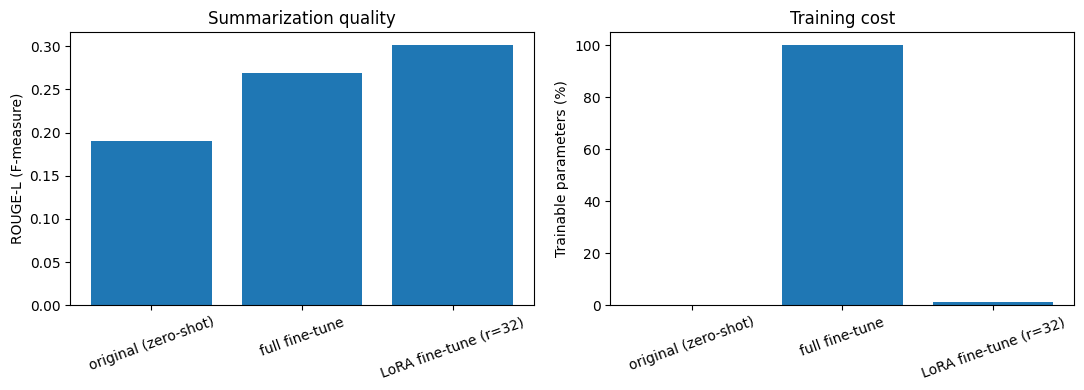

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(comparison_df["model"], comparison_df["rougeL"])
axes[0].set_ylabel("ROUGE-L (F-measure)")
axes[0].set_title("Summarization quality")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(comparison_df["model"], comparison_df["trainable_pct"])
axes[1].set_ylabel("Trainable parameters (%)")
axes[1].set_title("Training cost")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("results/comparison.png", dpi=150)
plt.show()

## 2. LoRA rank sweep

Original extension beyond the source lab: how does the LoRA rank `r` trade
off parameter count against summarization quality?

In [8]:
from src.pipeline import run_lora_rank_sweep

sweep_df = run_lora_rank_sweep(
    model_name="google/flan-t5-base",
    ranks=[4, 16, 32],
    train_size=1000,
    eval_size=100,
    test_size=50,
    num_train_epochs=1,
)
sweep_df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
10,1.614500
20,1.341500
30,1.369100
40,1.270100
50,1.316500
60,1.416300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
10,1.615700
20,1.338500
30,1.362600
40,1.267500
50,1.313100
60,1.418500


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
10,1.613600
20,1.336400
30,1.360800
40,1.266100
50,1.312800
60,1.416700


,lora_r,trainable_params,trainable_pct,train_time_sec,rouge1,rouge2,rougeL
0,4,442368,0.178360,82.591437,0.369049,0.123879,0.297624
1,16,1769472,0.709641,82.581301,0.349949,0.117752,0.295393
2,32,3538944,1.409282,82.661072,0.372414,0.108387,0.301144


In [9]:
sweep_df.to_csv("results/lora_rank_sweep.csv", index=False)
print("Saved results/lora_rank_sweep.csv")

Saved results/lora_rank_sweep.csv


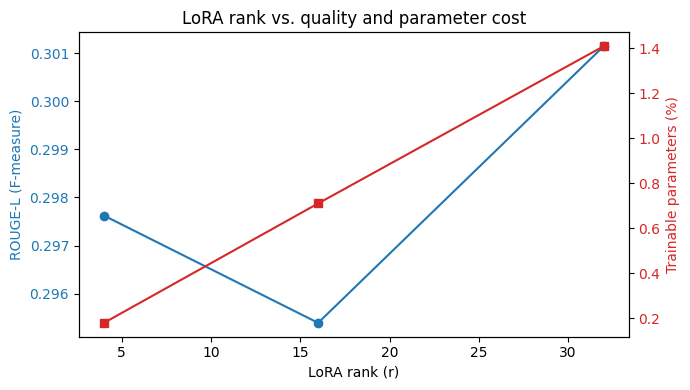

In [10]:
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(sweep_df["lora_r"], sweep_df["rougeL"], marker="o", color="tab:blue", label="ROUGE-L")
ax1.set_xlabel("LoRA rank (r)")
ax1.set_ylabel("ROUGE-L (F-measure)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sweep_df["lora_r"], sweep_df["trainable_pct"], marker="s", color="tab:red", label="Trainable %")
ax2.set_ylabel("Trainable parameters (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("LoRA rank vs. quality and parameter cost")
plt.tight_layout()
plt.savefig("results/lora_rank_sweep.png", dpi=150)
plt.show()

## Findings

_Fill this in after running the cells above:_

- How much ROUGE does full fine-tuning gain over zero-shot, and how much of
  that gain does LoRA (r=32) recover?
- Is the training-time gap between full fine-tuning and LoRA as large as the
  trainable-parameter gap suggests?
- In the rank sweep, does ROUGE-L keep improving from r=4 to r=32, or does it
  plateau? Where's the best quality-per-trainable-parameter tradeoff?